# Final Project
### In my final project, I used data from the CLOUPE Browser to gather cervical cancer cells from one patient and analyze the gene expression through several different methods. I first created volcano plots of six different clusters to analyze. Then, I trained a neural network to see if my model could correctly input the cells into the corresponding cluster. I chose two different regions in my UMAP visualization from CLOUPE to compare and contrast them.

## AI Use
### I used AI for my PCA plot code because I wanted to know how to label the top 20 genes of each cluster. I also got AI help to print the top 20 genes into a table. Additionally, I also got help from classmates and my friend in the CS department. My CS friend helped me fix up the code for the gene table and sorting out my data for my neural network. Other than that, I used previous labs or searched on Google for simple codes like changing the directory. 

In [2]:
# Import all packages
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from scipy import stats
import statsmodels.stats.multitest as smm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

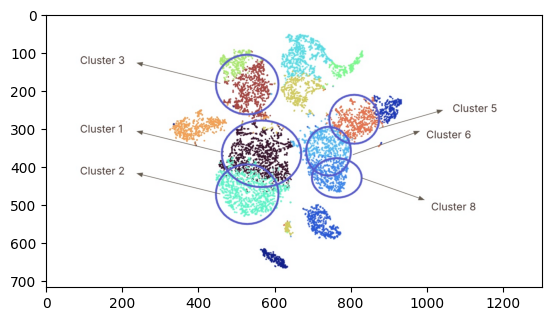

In [3]:
# Download necessary packages to load the photo
import matplotlib.image as mpimg
import cv2

# Define img to be our photo imported into this notebook. Then use the plotting library 
# ('plt.COMMAND') to plot the image
img = cv2.imread('CloupeData.jpg')
plt.imshow(img)
plt.show()

In [4]:
# Make sure we are in the correct directory. All of my volcano plots were failing and Mikayla helped me to realize that all of my files needed to be in the same folder.
%cd '/Users/havengarcia/Documents/2026 Spring Bio373 CompBio/Week 12/csv files'

/Users/havengarcia/Documents/2026 Spring Bio373 CompBio/Week 12/csv files


In [5]:
pwd

'/Users/havengarcia/Documents/2026 Spring Bio373 CompBio/Week 12/csv files'

In [6]:
# Create a definition to make plotting volcano plots much simpler. This was from lab 7, I had many issues but Mikayla helped me start this.

def create_volcanoplot(csv_file, gene_column="FeatureName", title="Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), highlight_color='red', annotate_top_n=40, ax=None):

    df = pd.read_csv(csv_file)

    if gene_column is not None and gene_column in df.columns:
        gene_names = df[gene_column].values
        df = df.drop(columns=[gene_column])
    else:
        gene_names = df.index.astype(str)

    log2_fold_changes = df["Log2 Fold Change"].values
    p_values = df["P-Value"].values

    p_values = np.nan_to_num(p_values, nan=1.0)
    neg_log_p = -np.log10(p_values)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.scatter(log2_fold_changes, neg_log_p,
               alpha=0.5, color='gray', s=30)

    significant = (abs(log2_fold_changes) > log2_fc_threshold) & (p_values < p_threshold)

    upregulated = significant & (log2_fold_changes > 0)
    downregulated = significant & (log2_fold_changes < 0)

# plot non-significant (gray)
    ax.scatter(log2_fold_changes[~significant],
           neg_log_p[~significant],
           alpha=0.5, color='gray', s=30)

# plot the upregulated (red)
    ax.scatter(log2_fold_changes[upregulated],
           neg_log_p[upregulated],
           color='red', s=30, label='Upregulated')

# plot the downregulated (blue)
    ax.scatter(log2_fold_changes[downregulated],
           neg_log_p[downregulated],
           color='blue', s=30, label='Downregulated')

    ax.axhline(y=-np.log10(p_threshold), color='blue', linestyle='--', alpha=0.3)
    ax.axvline(x=log2_fc_threshold, color='blue', linestyle='--', alpha=0.3)
    ax.axvline(x=-log2_fc_threshold, color='blue', linestyle='--', alpha=0.3)

    ax.set_xlabel("Log2 Fold Change")
    ax.set_ylabel("-Log10 P-value")
    ax.set_title(title)

    if annotate_top_n > 0:
        top_indices = np.argsort(neg_log_p)[-annotate_top_n:]

        for i in top_indices:
            if significant[i]:
                ax.annotate(gene_names[i],
                            (log2_fold_changes[i], neg_log_p[i]),
                            xytext=(5, 5),
                            textcoords='offset points',
                            fontsize=8)

    ax.grid(alpha=0.3)


    return fig, ax

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 1 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

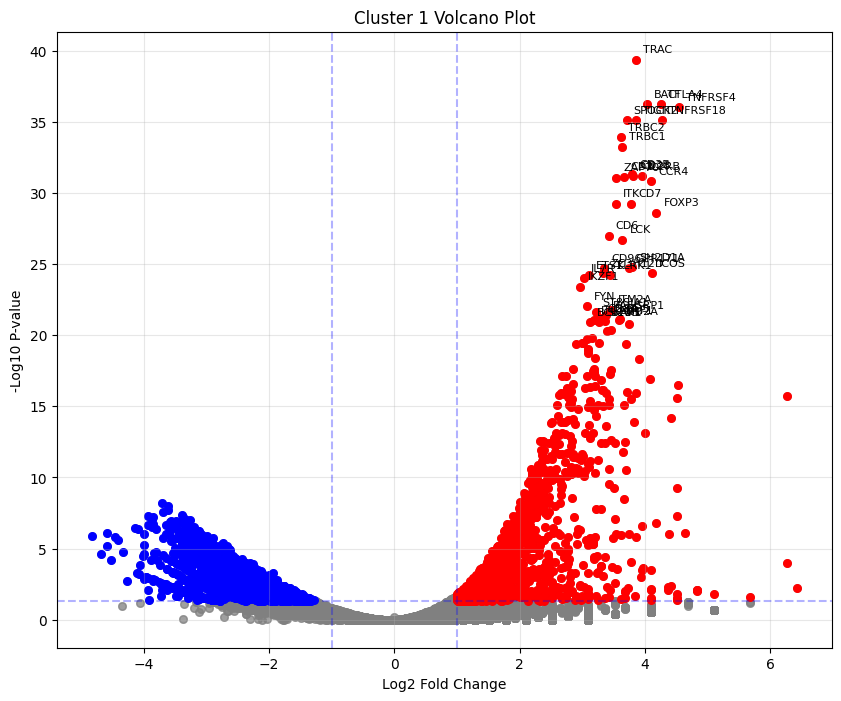

In [7]:
# Plot Each Cluster. Clusters 1,2,3 are in one region, while clusters 5,6,8 are in another.
create_volcanoplot('cluster 1.csv', gene_column="FeatureName", title="Cluster 1 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 2 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

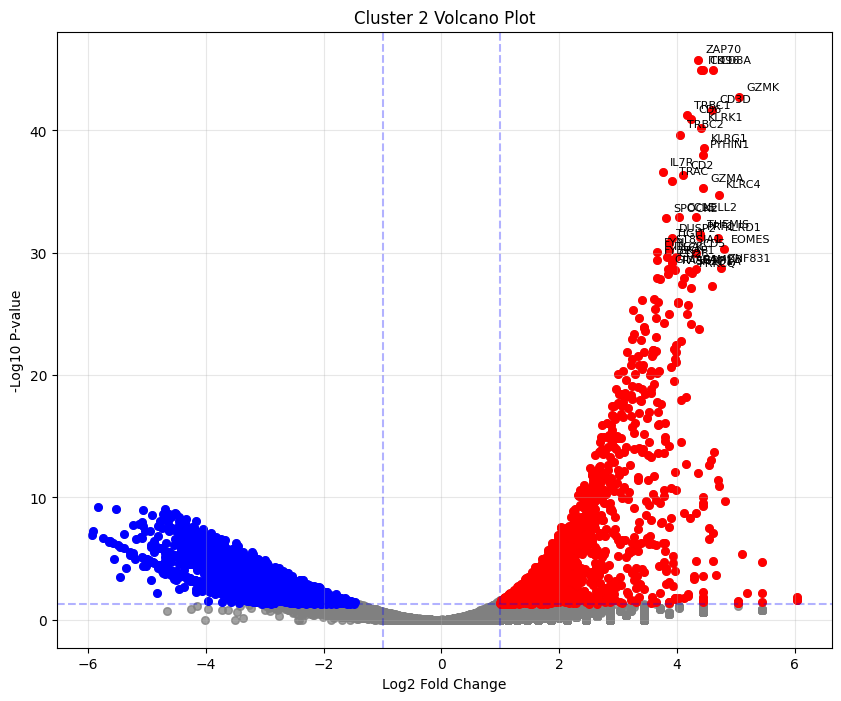

In [8]:
create_volcanoplot('cluster 2.csv', gene_column="FeatureName", title="Cluster 2 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 3 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

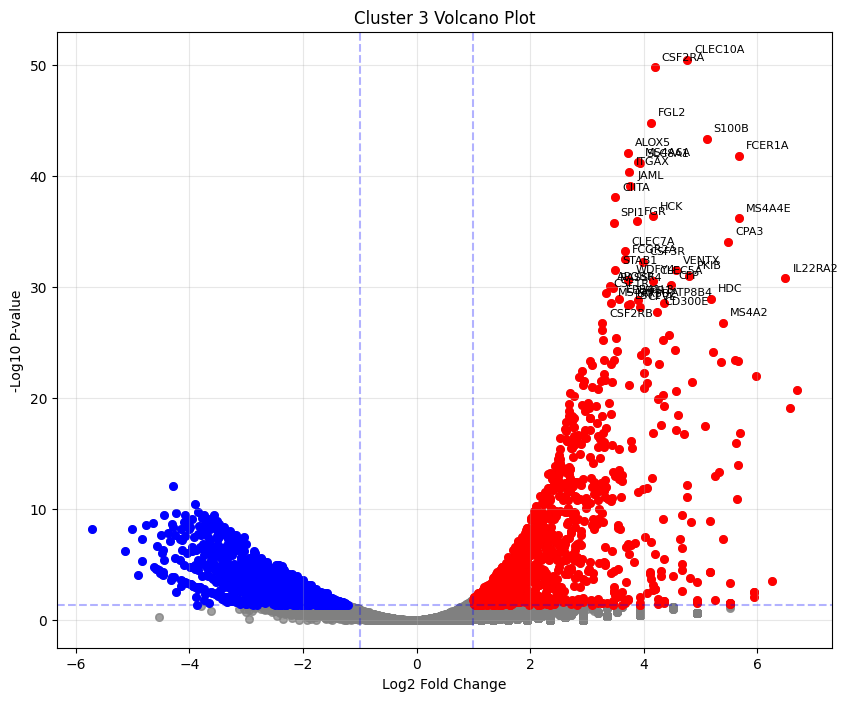

In [9]:
create_volcanoplot('cluster 3.csv', gene_column="FeatureName", title="Cluster 3 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 5 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

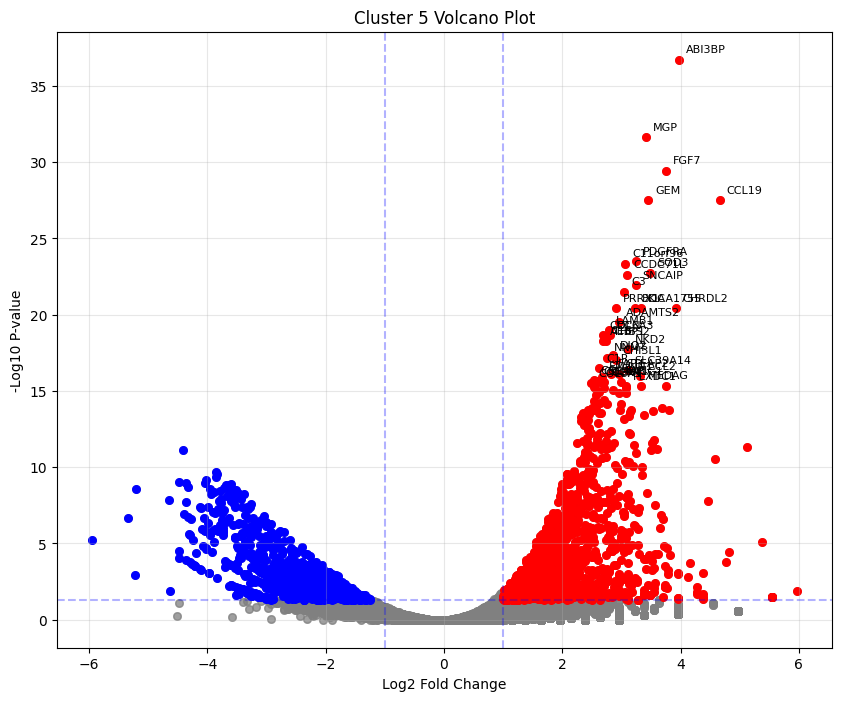

In [10]:
create_volcanoplot('cluster 5.csv', gene_column="FeatureName", title="Cluster 5 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 6 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

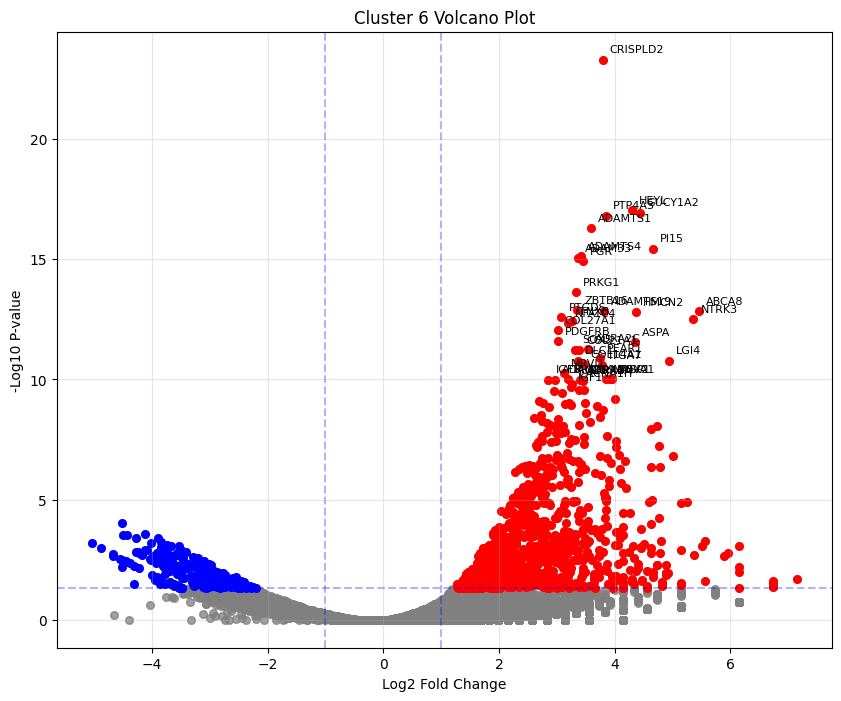

In [11]:
create_volcanoplot('cluster 6.csv', gene_column="FeatureName", title="Cluster 6 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 8 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

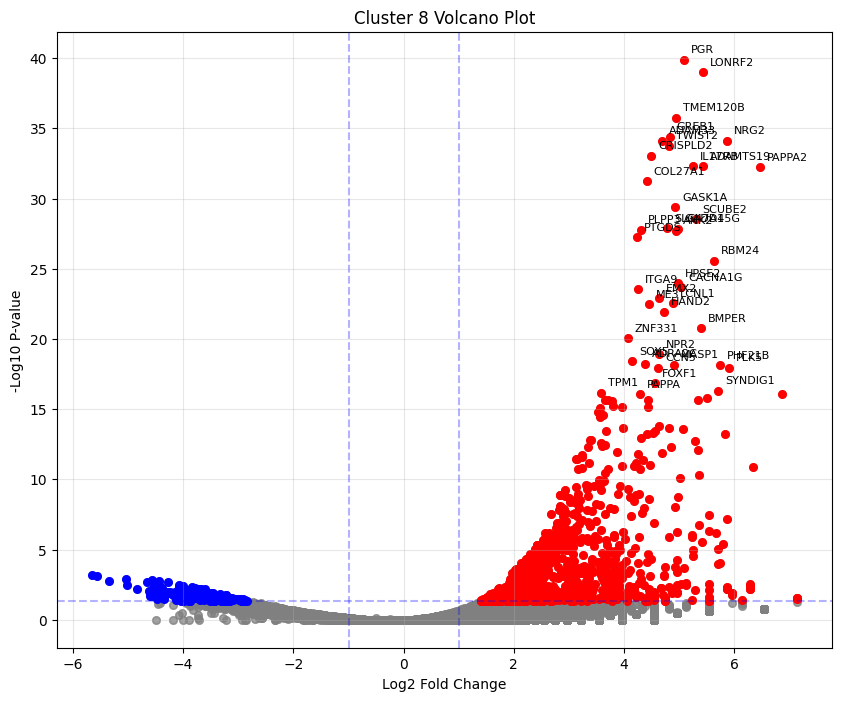

In [12]:
create_volcanoplot('cluster 8.csv', gene_column="FeatureName", title="Cluster 8 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

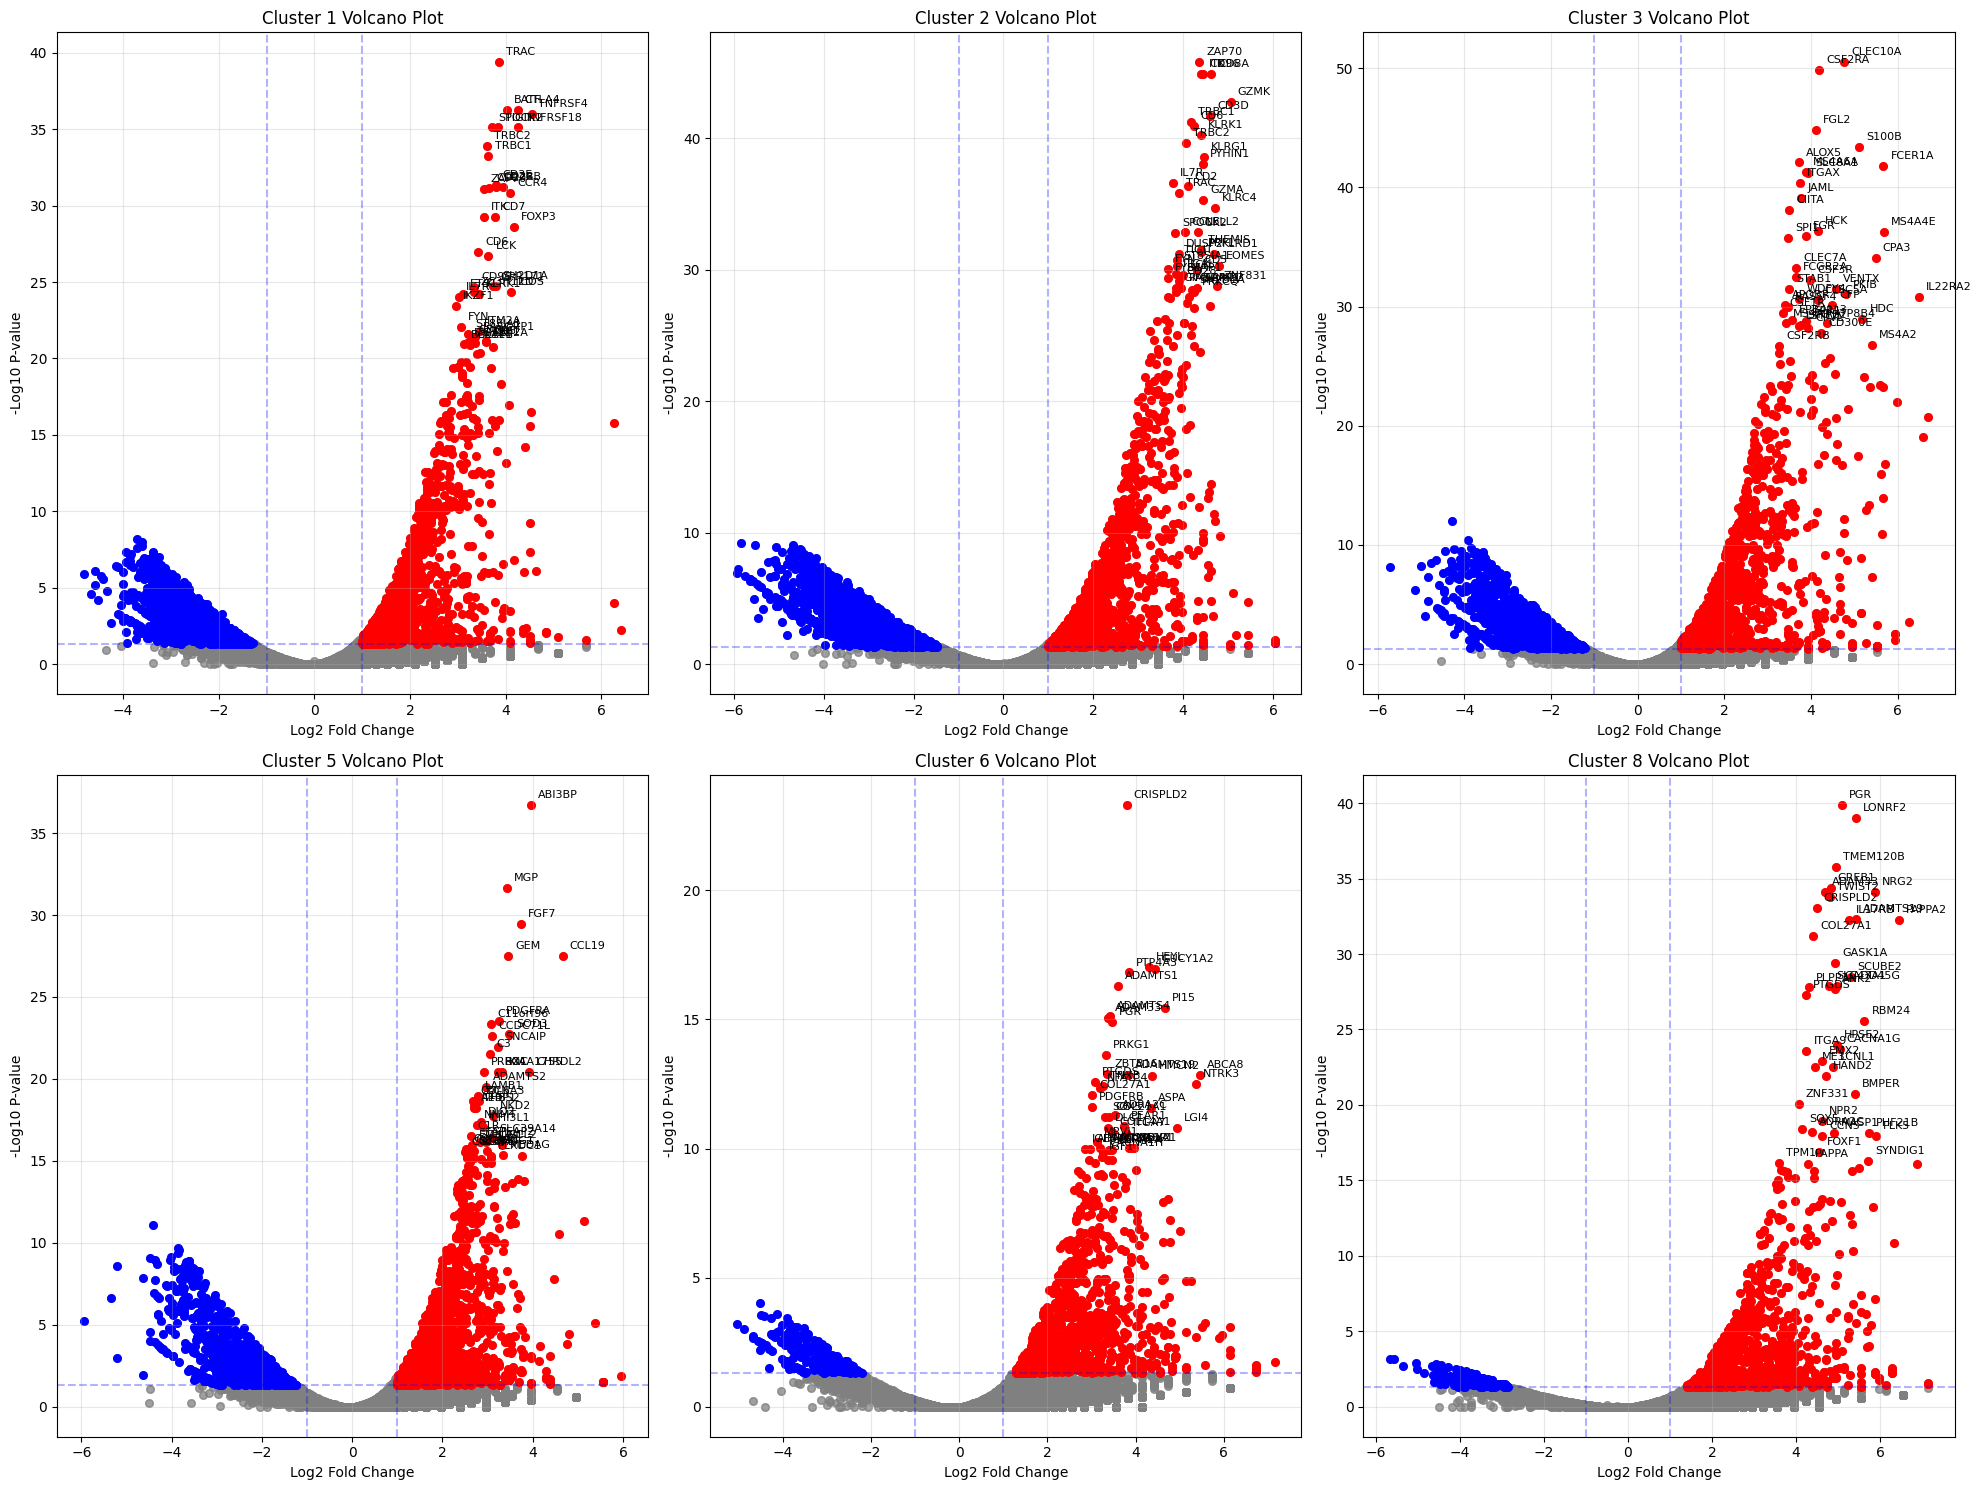

<Figure size 640x480 with 0 Axes>

In [14]:
# Plot the individual plots into one multi-panel figure to simplify visualization
import matplotlib.pyplot as plt

# I wanted to create a multi-panel figure that I can use for my paper, so I made each volcano plot a subplot.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
axes = axes.flatten()

# This is the list of clusters and their titles to make sure I am using the correct data.
cluster_data = [
    ('cluster 1.csv', 'Cluster 1 Volcano Plot'),
    ('cluster 2.csv', 'Cluster 2 Volcano Plot'),
    ('cluster 3.csv', 'Cluster 3 Volcano Plot'),
    ('cluster 5.csv', 'Cluster 5 Volcano Plot'),
    ('cluster 6.csv', 'Cluster 6 Volcano Plot'),
    ('cluster 8.csv', 'Cluster 8 Volcano Plot')
]

for i, (csv_file, title) in enumerate(cluster_data):
    current_ax = axes[i]
    create_volcanoplot(csv_file, gene_column="FeatureName", title=title, log2_fc_threshold=1, p_threshold=0.05,
                       annotate_top_n=40, ax=current_ax)

plt.tight_layout()
plt.show()

# Save as PNG
plt.savefig('volcanoplot.png', dpi=300)
plt.show()

# Training Neural Network and Confusion Matrix for Clusters 1,2,3

The next few codes are for training my model to create a neural network and a confusion matrix for Clusters 1,2,3.

In [36]:
# To train my neural network, I needed to load each cluster to make sure to indicate where the cells belong
c1 = pd.read_csv("cluster 1.csv")
c1['cluster_label'] = 0
c2 = pd.read_csv("cluster 2.csv")
c2['cluster_label'] = 1
c3 = pd.read_csv("cluster 3.csv")
c3['cluster_label'] = 2

In [37]:
df = pd.concat([c1, c2, c3], ignore_index=True)

In [38]:
df = pd.concat([c1, c2, c3], ignore_index=True)

# Defining what I want to classify.
X = df[["Log2 Fold Change", "P-Value"]].copy()
# This is the cluster label.
y = df["cluster_label"]

# This is to make sure that any missing P-Values are accounted for. Had to use Google for this.
X["P-Value"] = np.nan_to_num(X["P-Value"], nan=1.0)

In [39]:
# I kept getting errors because it was recognizing columns that were not numbers, so I plotted the column titles for verification
df.columns

Index(['FeatureID', 'FeatureName', 'Cluster 1 Average', 'Log2 Fold Change',
       'P-Value', 'cluster_label', 'Cluster 2 Average', 'Cluster 3 Average'],
      dtype='str')

In [40]:
# After some research and help from my CS friend, she showed me that I have to get rid of the columns that are not numbers in order to train neural network.
df = df.drop(columns=["FeatureID"])

In [41]:
df = df.drop(columns=["FeatureName"])

In [42]:
# Normalization of the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Train the neural network
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

This was taking awhile to load so I used Lab 7 as a foundation, but asked AI to tweak it to fit my dataset. 

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. Convert your existing data to PyTorch tensors
# Assuming training_data, testing_data, training_categories, testing_categories already exist
# and are numpy arrays or similar formats that can be converted to tensors

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(training_data)
y_train_tensor = torch.LongTensor(training_categories)
X_test_tensor = torch.FloatTensor(testing_data)
y_test_tensor = torch.LongTensor(testing_categories)

# 2. Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Define the neural network model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.batch_norm1 = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.layer2 = nn.Linear(hidden_size, hidden_size // 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_size // 2)
        self.layer3 = nn.Linear(hidden_size // 2, num_classes)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer3(x)
        return x

# 4. Initialize the model
input_size = X_train_tensor.shape[1]  # Number of features
hidden_size = 128
num_classes = len(torch.unique(y_train_tensor))  # Number of unique categories
model = NeuralNetwork(input_size, hidden_size, num_classes)

# 5. Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# 6. Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(test_loader)
    val_accuracy = 100 * val_correct / val_total
    
    # Update learning rate
    scheduler.step(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {epoch_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

# 7. Final evaluation
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    test_accuracy = 100 * correct / total
    print(f'Final Test Accuracy: {test_accuracy:.2f}%')

# 8. Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': num_classes,
    'input_size': input_size,
    'hidden_size': hidden_size
}, 'pytorch_model.pth')

# 9. Example of how to make predictions with the trained model
def predict(model, data):
    model.eval()
    with torch.no_grad():
        tensor_data = torch.FloatTensor(data)
        outputs = model(tensor_data)
        _, predicted = torch.max(outputs, 1)
        return predicted.numpy()

NameError: name 'training_data' is not defined

This is the final code that worked for me. I can validate the data through the number it gave me and use the confusion matrix as a way to see how accurate my data is. 

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# To train my neural network, I needed to load each cluster to make sure to indicate where the cells belong
c1 = pd.read_csv("cluster 1.csv")
c1['cluster_label'] = 0
c2 = pd.read_csv("cluster 2.csv")
c2['cluster_label'] = 1
c3 = pd.read_csv("cluster 3.csv")
c3['cluster_label'] = 2

# 1. Convert your existing data to PyTorch tensors
# Assuming training_data, testing_data, training_categories, testing_categories already exist
# and are numpy arrays or similar formats that can be converted to tensors

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
# If y_train is a pandas Series, we convert it to a numpy array first using .values
y_train_tensor = torch.LongTensor(y_train.values if isinstance(y_train, pd.Series) else y_train)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test.values if isinstance(y_test, pd.Series) else y_test)

# 2. Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Define the neural network model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.batch_norm1 = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.layer2 = nn.Linear(hidden_size, hidden_size // 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_size // 2)
        self.layer3 = nn.Linear(hidden_size // 2, num_classes)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer3(x)
        return x

# 4. Initialize the model
input_size = X_train_tensor.shape[1]             
hidden_size = 128
num_classes = len(torch.unique(y_train_tensor))  
model = NeuralNetwork(input_size, hidden_size, num_classes)

# 5. Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)


# 6. Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(test_loader)
    val_accuracy = 100 * val_correct / val_total
    
    # Update learning rate
    scheduler.step(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {epoch_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')


# 7. Final evaluation & collection of predictions (For Confusion Matrix!)
model.eval()
all_predictions = []

with torch.no_grad():
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Collect predictions to generate the confusion matrix
        all_predictions.extend(predicted.numpy())
    
    test_accuracy = 100 * correct / total
    print(f'\nFinal Test Accuracy: {test_accuracy:.2f}%')

Epoch [1/20], Train Loss: 1.0935, Train Acc: 38.32%, Val Loss: 1.0813, Val Acc: 39.45%
Epoch [2/20], Train Loss: 1.0872, Train Acc: 38.77%, Val Loss: 1.0806, Val Acc: 40.24%
Epoch [3/20], Train Loss: 1.0862, Train Acc: 39.02%, Val Loss: 1.0816, Val Acc: 39.29%
Epoch [4/20], Train Loss: 1.0858, Train Acc: 39.09%, Val Loss: 1.0818, Val Acc: 39.95%
Epoch [5/20], Train Loss: 1.0856, Train Acc: 38.90%, Val Loss: 1.0805, Val Acc: 40.29%
Epoch [6/20], Train Loss: 1.0850, Train Acc: 39.05%, Val Loss: 1.0816, Val Acc: 39.26%
Epoch [7/20], Train Loss: 1.0841, Train Acc: 39.40%, Val Loss: 1.0837, Val Acc: 39.27%
Epoch [8/20], Train Loss: 1.0837, Train Acc: 39.33%, Val Loss: 1.0801, Val Acc: 39.34%
Epoch [9/20], Train Loss: 1.0841, Train Acc: 39.18%, Val Loss: 1.0791, Val Acc: 39.87%
Epoch [10/20], Train Loss: 1.0828, Train Acc: 39.53%, Val Loss: 1.0784, Val Acc: 39.83%
Epoch [11/20], Train Loss: 1.0829, Train Acc: 39.47%, Val Loss: 1.0782, Val Acc: 40.64%
Epoch [12/20], Train Loss: 1.0828, Train 

# Verification of Neural Network
## To verify that my neural network was accurate, I created a confusion matrix for the clusters below. I was able to compare the True Negatives, False Negatives, True Positives, and False Positives. In addition, PCA plots were created to evaluate the model, but I think the similarities of the cells were too great, and could not really form distinct clusters. However, since the dataset is very large, the confusion matrix was a good way to measure accuracy. 

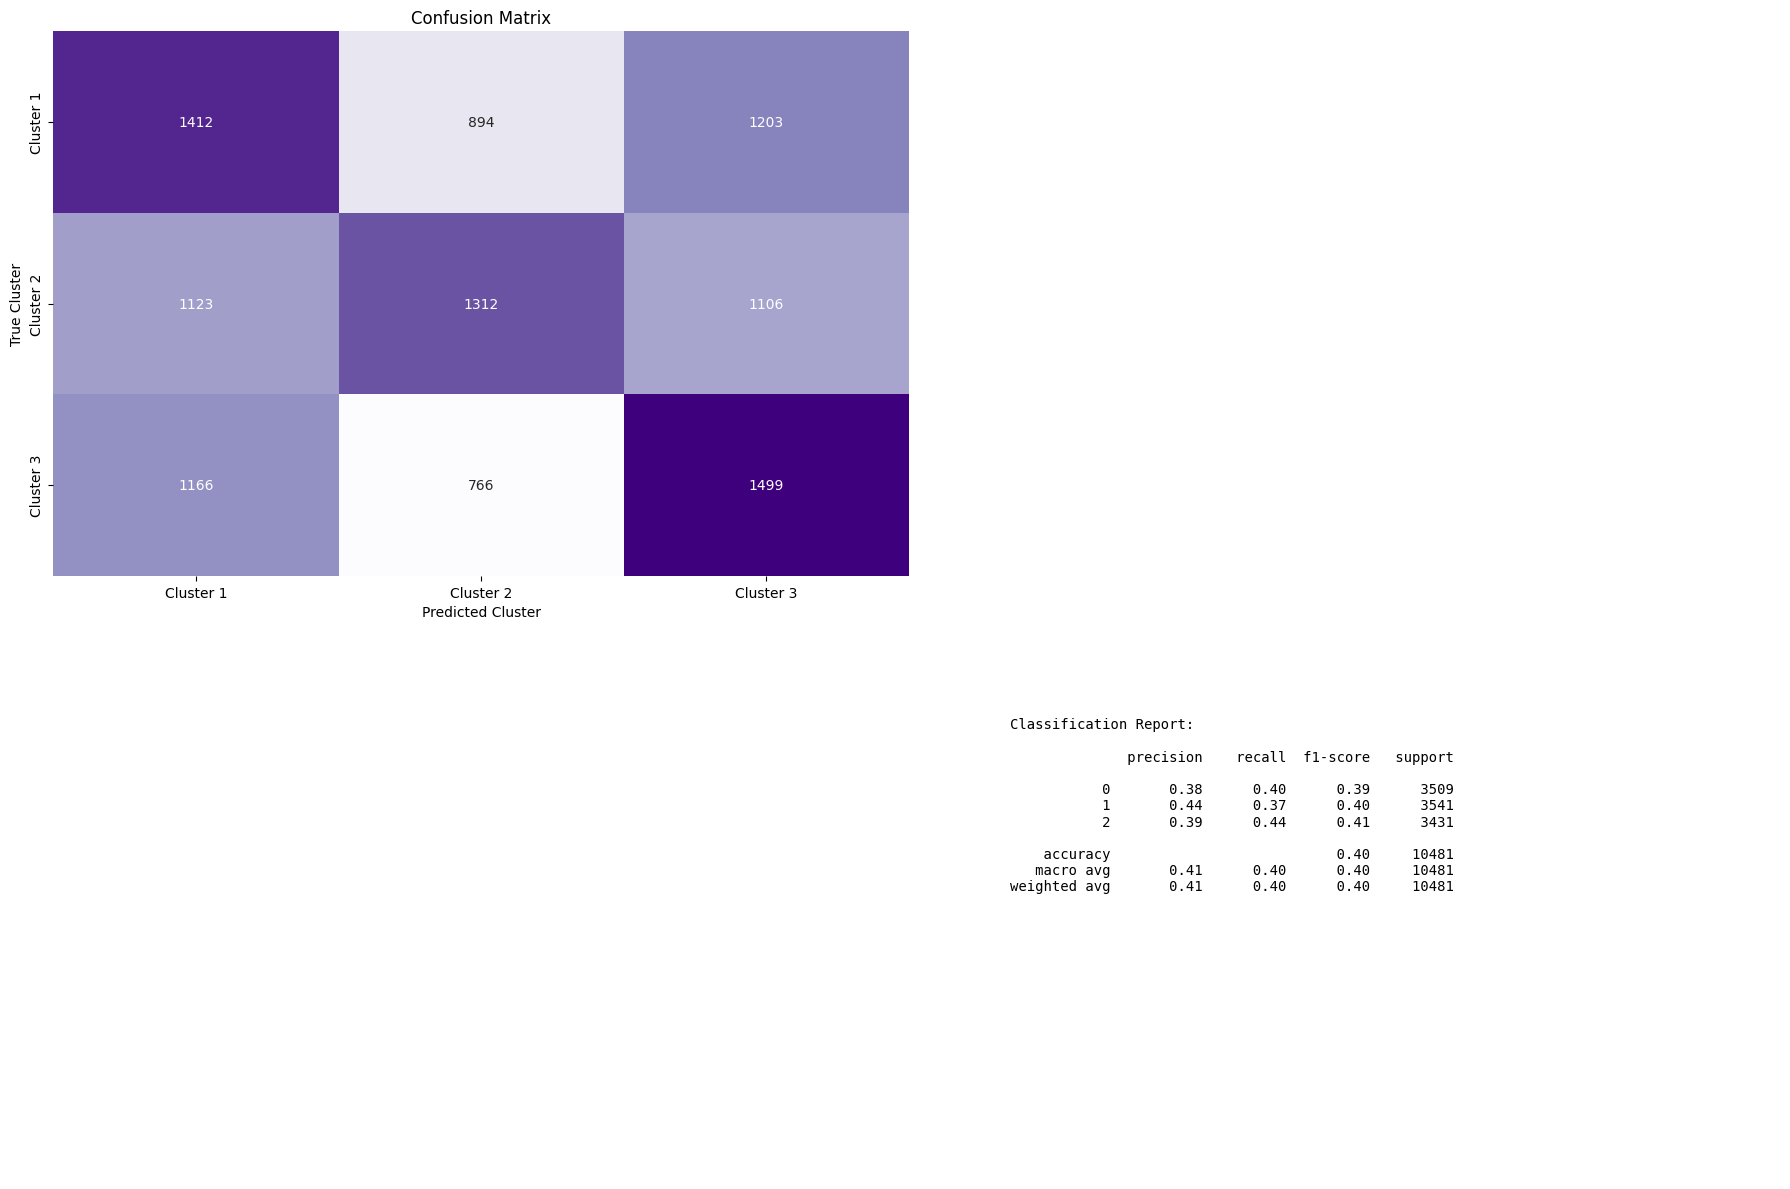

Overall Accuracy: 0.4029

Class Distribution in Test Data:
Class 0: 3509 samples
Class 1: 3541 samples
Class 2: 3431 samples


In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics

# Set model to evaluation mode
model.eval()

# Lists to store true labels and predictions
all_preds = []
all_labels = []
all_probs = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move to the same device as the model
        inputs = inputs.to(next(model.parameters()).device)
        labels = labels.to(next(model.parameters()).device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Get predicted class (for multi-class, take the argmax)
        if outputs.shape[1] > 1:  # Multi-class case
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            class_probs = probs[:, 1].cpu().numpy() if probs.shape[1] >= 2 else probs.cpu().numpy()
        else:  # Binary classification case
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            class_probs = probs.cpu().numpy().flatten()
        
        # Collect predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(class_probs)

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

cluster_labels = ['Cluster 1', 'Cluster 2', 'Cluster 3']

# Create a figure with subplots
plt.figure(figsize=(18, 12))

# 1. Confusion Matrix
plt.subplot(2, 2, 1)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
           xticklabels=cluster_labels, yticklabels=cluster_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Cluster')
plt.xlabel('Predicted Cluster')


# 4. Classification Report as Text
plt.subplot(2, 2, 4)
plt.axis('off')
report = classification_report(all_labels, all_preds)
plt.text(0.1, 0.5, f"Classification Report:\n\n{report}", fontsize=10, family='monospace')

plt.tight_layout()
plt.show()

# Print overall accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Overall Accuracy: {accuracy:.4f}")

# If you want to see the class distribution
unique_labels, counts = np.unique(all_labels, return_counts=True)
print("\nClass Distribution in Test Data:")
for label, count in zip(unique_labels, counts):
    print(f"Class {label}: {count} samples")

### Neural Network and Confusion Matrix for Clusters 5, 6, and 8

After creating a confusion matrix for Clusters 1,2,3, I wanted to create one for Clusters 5,6,8. I wanted to make a confusion matrix for both regions.

In [88]:
# To train my neural network, I needed to load each cluster to make sure to indicate where the cells belong
c1 = pd.read_csv("cluster 5.csv")
c1['cluster_label'] = 0
c2 = pd.read_csv("cluster 6.csv")
c2['cluster_label'] = 1
c3 = pd.read_csv("cluster 8.csv")
c3['cluster_label'] = 2

# 1. Convert my existing data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)

y_train_tensor = torch.LongTensor(y_train.values if isinstance(y_train, pd.Series) else y_train)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test.values if isinstance(y_test, pd.Series) else y_test)

# 2. Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Define the neural network model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.batch_norm1 = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.layer2 = nn.Linear(hidden_size, hidden_size // 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_size // 2)
        self.layer3 = nn.Linear(hidden_size // 2, num_classes)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer3(x)
        return x

# 4. Initialize the model
input_size = X_train_tensor.shape[1]             
hidden_size = 128
num_classes = len(torch.unique(y_train_tensor))  
model = NeuralNetwork(input_size, hidden_size, num_classes)

# 5. Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)


# 6. Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(test_loader)
    val_accuracy = 100 * val_correct / val_total
    
    # Update learning rate
    scheduler.step(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {epoch_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')


# 7. Final evaluation & collection of predictions (For Confusion Matrix!)
model.eval()
all_predictions = []

with torch.no_grad():
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Collect predictions to generate the confusion matrix
        all_predictions.extend(predicted.numpy())
    
    test_accuracy = 100 * correct / total
    print(f'\nFinal Test Accuracy: {test_accuracy:.2f}%')

Epoch [1/20], Train Loss: 1.0968, Train Acc: 37.68%, Val Loss: 1.0825, Val Acc: 38.96%
Epoch [2/20], Train Loss: 1.0871, Train Acc: 38.85%, Val Loss: 1.0822, Val Acc: 39.98%
Epoch [3/20], Train Loss: 1.0866, Train Acc: 39.13%, Val Loss: 1.0807, Val Acc: 39.37%
Epoch [4/20], Train Loss: 1.0856, Train Acc: 39.24%, Val Loss: 1.0820, Val Acc: 40.14%
Epoch [5/20], Train Loss: 1.0846, Train Acc: 39.11%, Val Loss: 1.0812, Val Acc: 39.40%
Epoch [6/20], Train Loss: 1.0848, Train Acc: 39.21%, Val Loss: 1.0808, Val Acc: 40.73%
Epoch [7/20], Train Loss: 1.0851, Train Acc: 39.23%, Val Loss: 1.0784, Val Acc: 40.53%
Epoch [8/20], Train Loss: 1.0835, Train Acc: 39.16%, Val Loss: 1.0788, Val Acc: 39.85%
Epoch [9/20], Train Loss: 1.0838, Train Acc: 39.02%, Val Loss: 1.0809, Val Acc: 39.79%
Epoch [10/20], Train Loss: 1.0831, Train Acc: 39.29%, Val Loss: 1.0803, Val Acc: 39.99%
Epoch [11/20], Train Loss: 1.0829, Train Acc: 39.28%, Val Loss: 1.0781, Val Acc: 40.95%
Epoch [12/20], Train Loss: 1.0833, Train 

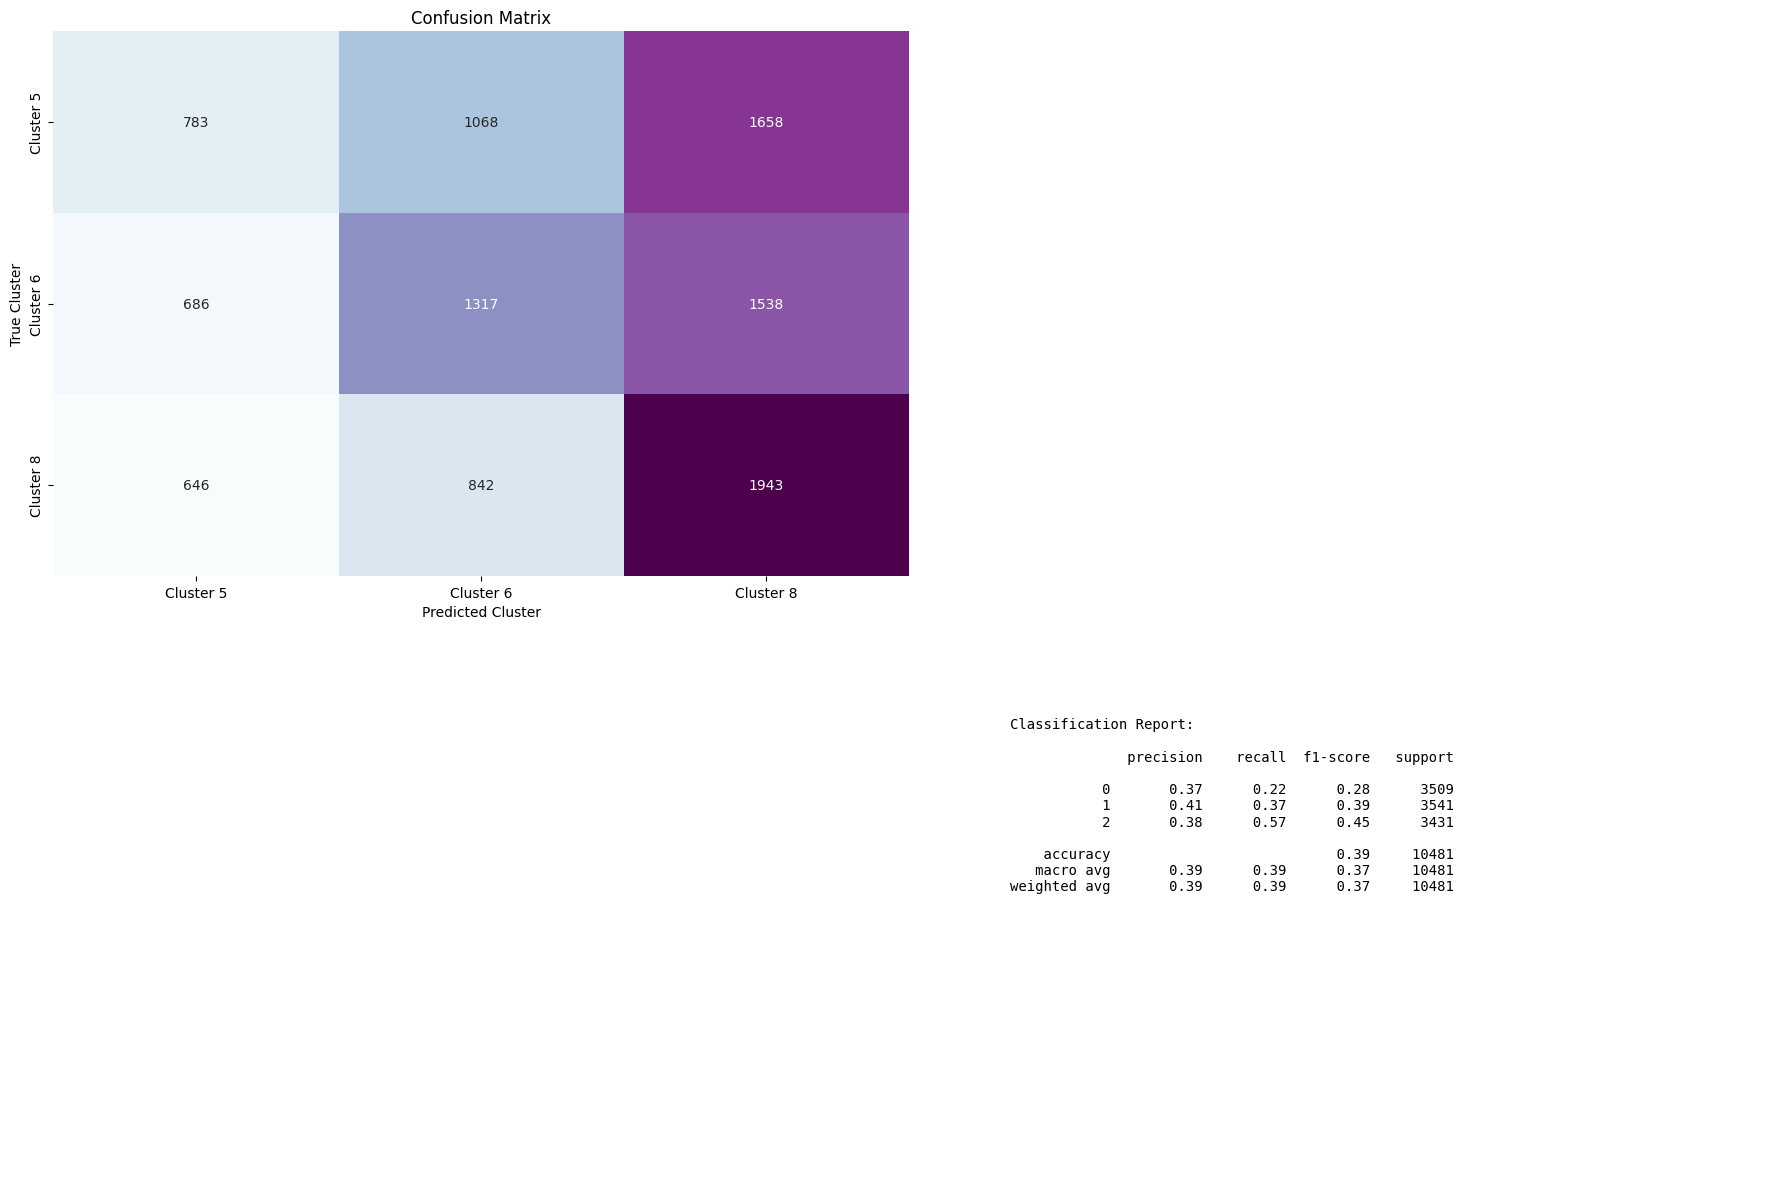

Overall Accuracy: 0.3857

Class Distribution in Test Data:
Class 0: 3509 samples
Class 1: 3541 samples
Class 2: 3431 samples


In [89]:

# Set model to evaluation mode
model.eval()

# Lists to store true labels and predictions
all_preds = []
all_labels = []
all_probs = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move to the same device as the model
        inputs = inputs.to(next(model.parameters()).device)
        labels = labels.to(next(model.parameters()).device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Get predicted class (for multi-class, take the argmax)
        if outputs.shape[1] > 1:  # Multi-class case
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            class_probs = probs[:, 1].cpu().numpy() if probs.shape[1] >= 2 else probs.cpu().numpy()
        else:  # Binary classification case
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            class_probs = probs.cpu().numpy().flatten()
        
        # Collect predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(class_probs)

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

cluster_labels = ['Cluster 5', 'Cluster 6', 'Cluster 8']

# Create a figure with subplots
plt.figure(figsize=(18, 12))

# 1. Confusion Matrix
plt.subplot(2, 2, 1)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', cbar=False,
           xticklabels=cluster_labels, yticklabels=cluster_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Cluster')
plt.xlabel('Predicted Cluster')


# 4. Classification Report as Text
plt.subplot(2, 2, 4)
plt.axis('off')
report = classification_report(all_labels, all_preds)
plt.text(0.1, 0.5, f"Classification Report:\n\n{report}", fontsize=10, family='monospace')

plt.tight_layout()
plt.show()

# Print overall accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Overall Accuracy: {accuracy:.4f}")

# If you want to see the class distribution
unique_labels, counts = np.unique(all_labels, return_counts=True)
print("\nClass Distribution in Test Data:")
for label, count in zip(unique_labels, counts):
    print(f"Class {label}: {count} samples")

### PCA Plot

To visualize the data, I wanted to use a Principal Component Analysis (PCA) plot. By doing this, I can identify the maximum variance and visualize the data from a different perspective. I made sure to identify each cluster by assigning it a color. I also wanted to identify the genes that are outliers, so I made sure to label them. I used some help from AI to see what was going wrong and editing as I went.

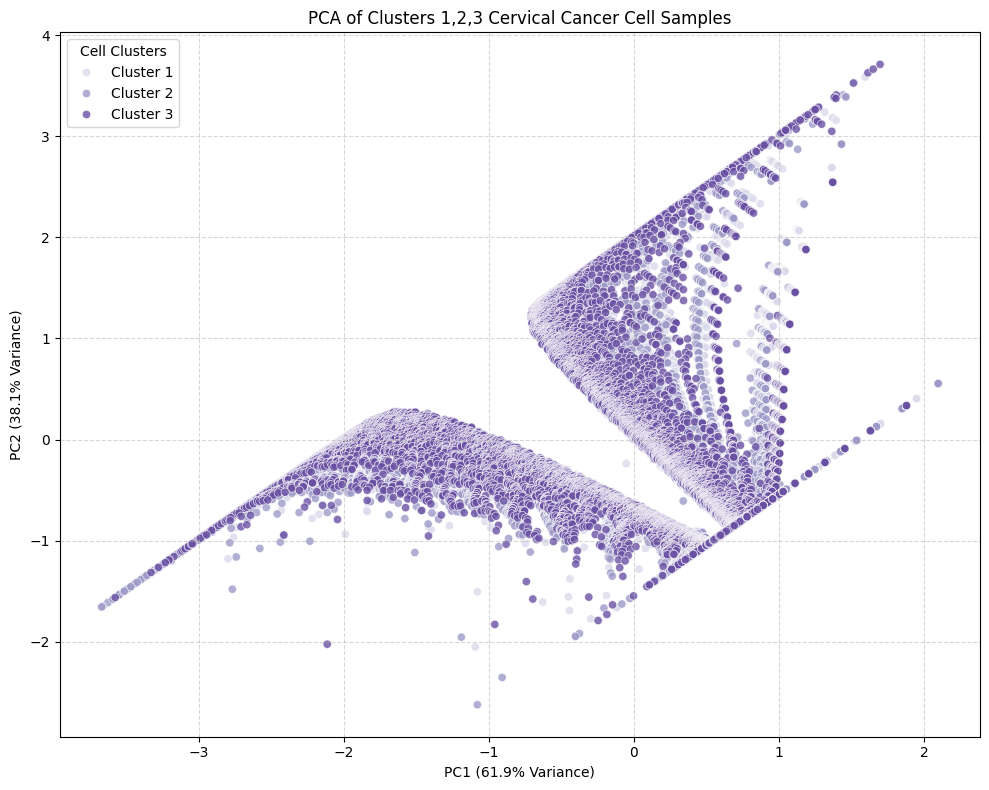

Explained variance ratio: [0.6190335 0.3809665]
Total variance explained: 1.00


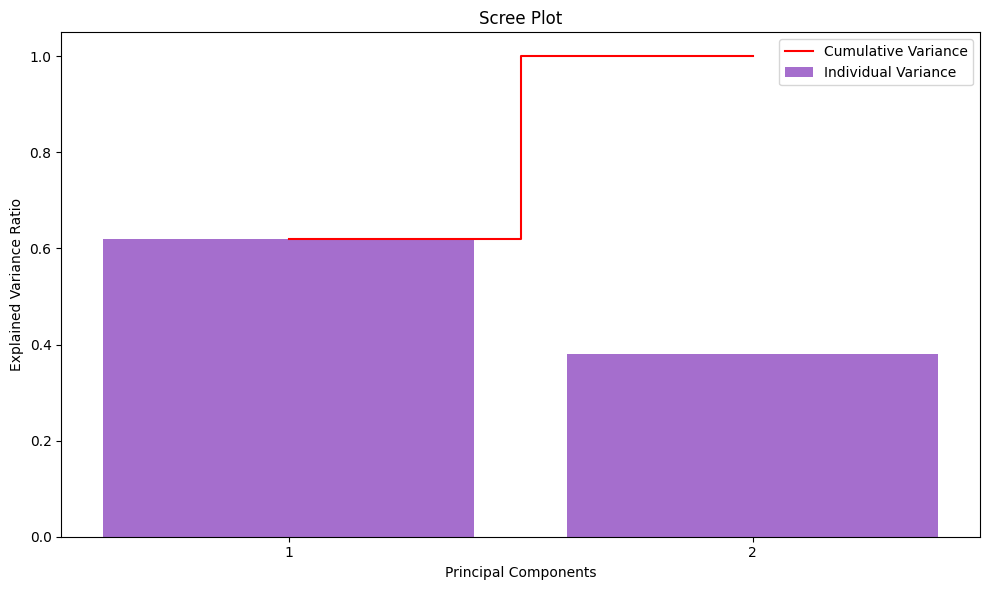

In [91]:
# Re-load data for clusters 1, 2, and 3 to get the 'FeatureName'
c1_annot = pd.read_csv("cluster 1.csv")
c1_annot['cluster_label'] = 0
c2_annot = pd.read_csv("cluster 2.csv")
c2_annot['cluster_label'] = 1
c3_annot = pd.read_csv("cluster 3.csv")
c3_annot['cluster_label'] = 2

# 1. Prepare and Run PCA on your Scaled Data
pca = PCA(n_components=2)  # 2 components for 2D visualization
pca_result = pca.fit_transform(X_scaled)

# Create a dataframe with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1]
})

# Map your numerical y values (0, 1, 2) to their actual cluster names for the legend
cluster_map = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'}
pca_df['Cluster'] = pd.Series(y).map(cluster_map).values


# 2. Plot the PCA Scatter Plot
plt.figure(figsize=(10, 8))

# Scatter plot colored by Cluster
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='Purples',  
    data=pca_df,
    alpha=0.8
)

plt.title('PCA of Clusters 1,2,3 Cervical Cancer Cell Samples')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cell Clusters')
plt.tight_layout()
plt.show()

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2f}")

# 3. Create the Scree Plot
plt.figure(figsize=(10, 6))
# Using range(1, 3) since we only extracted 2 principal components
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.6, color='#6a0dad', label='Individual Variance')
plt.step(range(1, 3), np.cumsum(pca.explained_variance_ratio_), where='mid', color='red', label='Cumulative Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot')
plt.xticks([1, 2])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### PCA Plot for Clusters 5, 6, and 8 

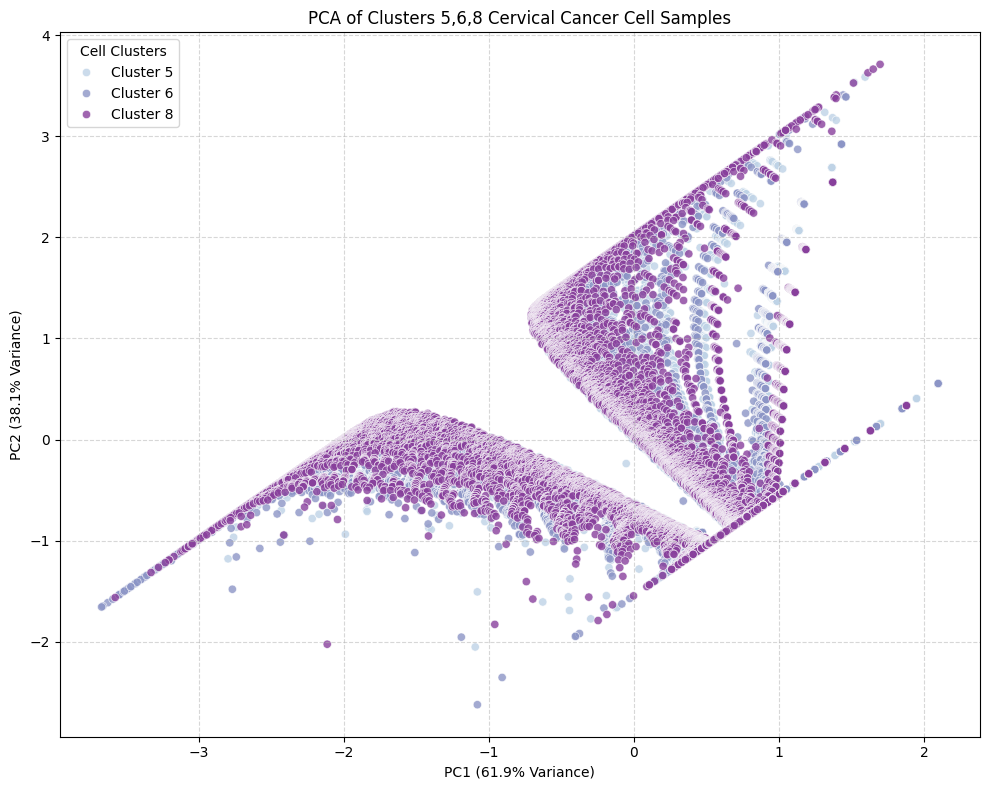

Explained variance ratio: [0.6190335 0.3809665]
Total variance explained: 1.00


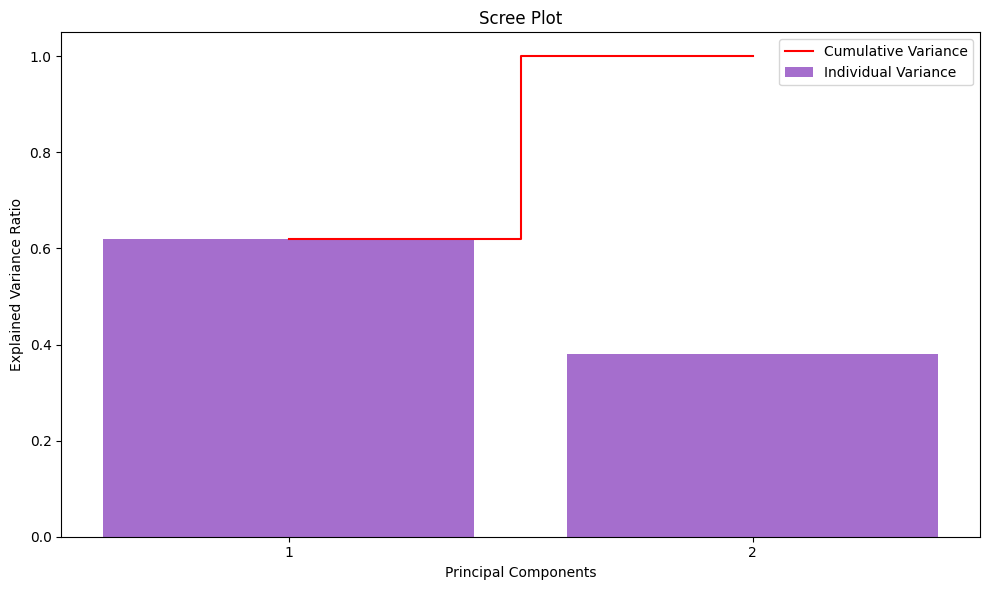

In [90]:
# Re-load data for clusters 1, 2, and 3 to get the 'FeatureName'
c1_annot = pd.read_csv("cluster 5.csv")
c1_annot['cluster_label'] = 0
c2_annot = pd.read_csv("cluster 6.csv")
c2_annot['cluster_label'] = 1
c3_annot = pd.read_csv("cluster 8.csv")
c3_annot['cluster_label'] = 2

# 1. Prepare and Run PCA on your Scaled Data
pca = PCA(n_components=2)  # 2 components for 2D visualization
pca_result = pca.fit_transform(X_scaled)

# Create a dataframe with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1]
})

# Map your numerical y values (0, 1, 2) to their actual cluster names for the legend
cluster_map = {0: 'Cluster 5', 1: 'Cluster 6', 2: 'Cluster 8'}
pca_df['Cluster'] = pd.Series(y).map(cluster_map).values


# 2. Plot the PCA Scatter Plot
plt.figure(figsize=(10, 8))

# Scatter plot colored by Cluster
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='BuPu',  
    data=pca_df,
    alpha=0.8
)

plt.title('PCA of Clusters 5,6,8 Cervical Cancer Cell Samples')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cell Clusters')
plt.tight_layout()
plt.show()

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2f}")

# 3. Create the Scree Plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.6, color='#6a0dad', label='Individual Variance')
plt.step(range(1, 3), np.cumsum(pca.explained_variance_ratio_), where='mid', color='red', label='Cumulative Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot')
plt.xticks([1, 2])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Combining all of my data into one PCA plot
I wanted to have a PCA plot that combined all my data together to visualize any similarities or differences. I thought it was good to create one for each region but I wanted one that represented everything as well.

In [79]:
# Reload all of the data to make sure the correct csv files have the correct label
c1_pca = pd.read_csv("cluster 1.csv")
c1_pca['cluster_label'] = 0
c2_pca = pd.read_csv("cluster 2.csv")
c2_pca['cluster_label'] = 1
c3_pca = pd.read_csv("cluster 3.csv")
c3_pca['cluster_label'] = 2
c5_pca = pd.read_csv("cluster 5.csv")
c5_pca['cluster_label'] = 3
c6_pca = pd.read_csv("cluster 6.csv")
c6_pca['cluster_label'] = 4
c8_pca = pd.read_csv("cluster 8.csv")
c8_pca['cluster_label'] = 5

# 1. Prepare and Run PCA on your Scaled Data
pca = PCA(n_components=2)  # 2 components for 2D visualization
pca_result = pca.fit_transform(X_scaled)

# Create a dataframe with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1]
})

# Map your numerical y values (0, 1, 2) to their actual cluster names for the legend
cluster_map = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 5', 4: 'Cluster 6', 5: 'Cluster 8}
pca_df['Cluster'] = pd.Series(y).map(cluster_map).values


# 2. Plot the PCA Scatter Plot
plt.figure(figsize=(10, 8))

# Scatter plot colored by Cluster
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='BuPu',  
    data=pca_df,
    alpha=0.8
)

plt.title('PCA of All Cervical Cancer Cell Samples')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cell Clusters')
plt.tight_layout()
plt.show()

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2f}")

# 3. Create the Scree Plot
plt.figure(figsize=(10, 6))
# Using range(1, 3) since we only extracted 2 principal components
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.6, color='#6a0dad', label='Individual Variance')
plt.step(range(1, 3), np.cumsum(pca.explained_variance_ratio_), where='mid', color='red', label='Cumulative Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot')
plt.xticks([1, 2])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 26) (3099810386.py, line 26)

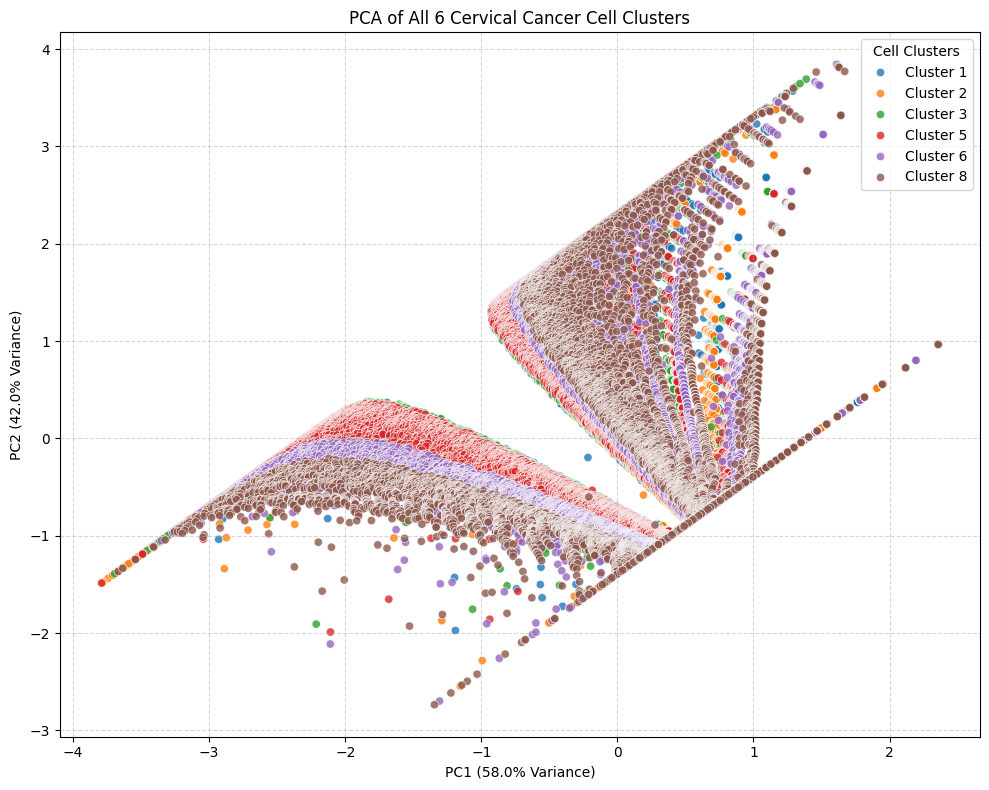

Explained variance ratio: [0.57958477 0.42041523]
Total variance explained: 1.00


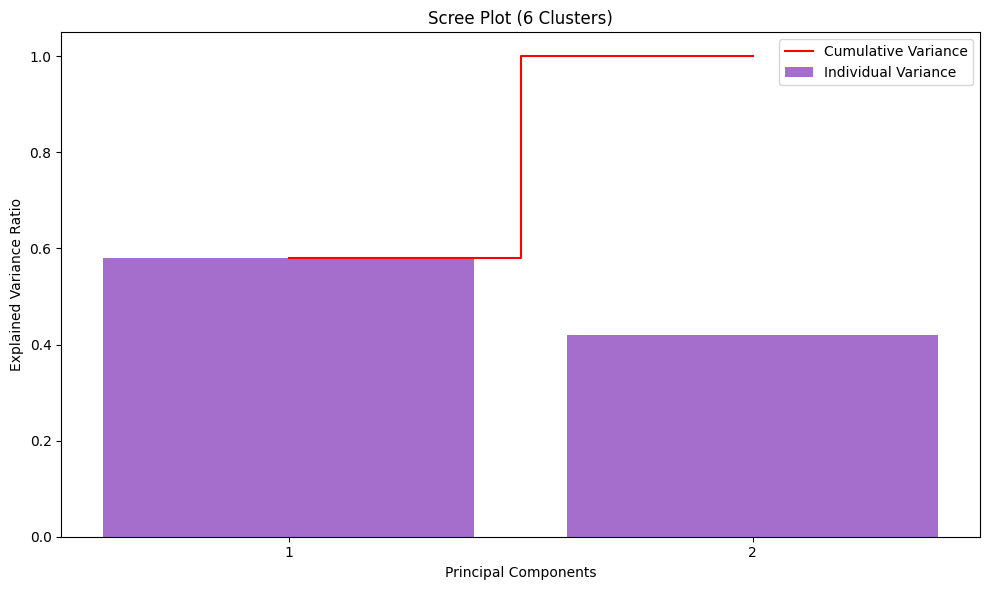

In [92]:
# 1. Load and combine ALL 6 cluster CSV files
c1_pca = pd.read_csv("cluster 1.csv")
c1_pca['cluster_label'] = 0

c2_pca = pd.read_csv("cluster 2.csv")
c2_pca['cluster_label'] = 1

c3_pca = pd.read_csv("cluster 3.csv")
c3_pca['cluster_label'] = 2

c5_pca = pd.read_csv("cluster 5.csv")
c5_pca['cluster_label'] = 3

c6_pca = pd.read_csv("cluster 6.csv")
c6_pca['cluster_label'] = 4

c8_pca = pd.read_csv("cluster 8.csv")
c8_pca['cluster_label'] = 5

# Combine all dataframes
df_all = pd.concat([c1_pca, c2_pca, c3_pca, c5_pca, c6_pca, c8_pca], ignore_index=True)

# Separate features (X) and labels (y)
X_all = df_all[["Log2 Fold Change", "P-Value"]].copy()
y_all = df_all["cluster_label"]

# Handle potential NaN values
X_all["P-Value"] = np.nan_to_num(X_all["P-Value"], nan=1.0)

# 2. Standardize the combined 6-cluster dataset
scaler_all = StandardScaler()
X_scaled_all = scaler_all.fit_transform(X_all)

# 3. Run PCA
pca_all = PCA(n_components=2)
pca_result_all = pca_all.fit_transform(X_scaled_all)

# Create a dataframe with PCA results
pca_df_all = pd.DataFrame({
    'PC1': pca_result_all[:, 0],
    'PC2': pca_result_all[:, 1]
})

# Map all 6 numeric labels to their respective cluster names
cluster_map_all = {
    0: 'Cluster 1', 
    1: 'Cluster 2', 
    2: 'Cluster 3', 
    3: 'Cluster 5', 
    4: 'Cluster 6', 
    5: 'Cluster 8'
}
pca_df_all['Cluster'] = pd.Series(y_all).map(cluster_map_all).values

# 4. Plot the 6-Cluster PCA Scatter Plot
plt.figure(figsize=(10, 8))

# Using a palette that has enough distinct colors for 6 categories (e.g., 'tab10' or 'Set2')
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='tab10',  
    data=pca_df_all,
    alpha=0.8
)

plt.title('PCA of All 6 Cervical Cancer Cell Clusters')
plt.xlabel(f'PC1 ({pca_all.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca_all.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cell Clusters')
plt.tight_layout()
plt.show()

# Print explained variance
print(f"Explained variance ratio: {pca_all.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca_all.explained_variance_ratio_):.2f}")

# 5. Create the Scree Plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, 3), pca_all.explained_variance_ratio_, alpha=0.6, color='#6a0dad', label='Individual Variance')
plt.step(range(1, 3), np.cumsum(pca_all.explained_variance_ratio_), where='mid', color='red', label='Cumulative Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot (6 Clusters)')
plt.xticks([1, 2])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Top 20 Genes for Each Cluster

These tables list the top 20 genes that are furthest from the origin in the PCA space for each individual cluster. The genes shown are considered the most 'extreme' and could possibly be the most influential in defining the separation of each respective cluster. I did reference our old lab, but it was not working with my data, so I asked my CS friend for help. She still could not figure it out, so I asked AI for some help with "FixCode" but used it as a guide. 

In [81]:
# AI Generated
# Reload all of the data to make sure the correct csv files have the correct label
c1_pca_annot = pd.read_csv("cluster 1.csv")
c1_pca_annot['cluster_label'] = 0
c2_pca_annot = pd.read_csv("cluster 2.csv")
c2_pca_annot['cluster_label'] = 1
c3_pca_annot = pd.read_csv("cluster 3.csv")
c3_pca_annot['cluster_label'] = 2
c5_pca_annot = pd.read_csv("cluster 5.csv")
c5_pca_annot['cluster_label'] = 3
c6_pca_annot = pd.read_csv("cluster 6.csv")
c6_pca_annot['cluster_label'] = 4
c8_pca_annot = pd.read_csv("cluster 8.csv")
c8_pca_annot['cluster_label'] = 5

# Link all dataframes
df_combined_pca_annot = pd.concat([c1_pca_annot, c2_pca_annot, c3_pca_annot, c5_pca_annot, c6_pca_annot, c8_pca_annot], ignore_index=True)

# Make sure the features I want are obtained.
X_combined_pca_annot = df_combined_pca_annot[["Log2 Fold Change", "P-Value"]].copy()
y_combined_pca_annot = df_combined_pca_annot["cluster_label"]

X_combined_pca_annot["P-Value"] = np.nan_to_num(X_combined_pca_annot["P-Value"], nan=1.0)

# Features must be scaled
scaler_combined_pca_annot = StandardScaler()
X_scaled_combined_pca_annot = scaler_combined_pca_annot.fit_transform(X_combined_pca_annot)

# Perform PCA
pca_combined_annot = PCA(n_components=2)
pca_components_combined_annot = pca_combined_annot.fit_transform(X_scaled_combined_pca_annot)

# Need a dataframe for plotting the PCA
pca_df_combined_annot = pd.DataFrame(data=pca_components_combined_annot, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_combined_annot['cluster_label'] = y_combined_pca_annot.reset_index(drop=True)
pca_df_combined_annot['FeatureName'] = df_combined_pca_annot['FeatureName'].reset_index(drop=True)

# Make sure features I wanted are printed
cluster_label_map_combined = {
    0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3',
    3: 'Cluster 5', 4: 'Cluster 6', 5: 'Cluster 8'
}
pca_df_combined_annot['cluster_label_name'] = pca_df_combined_annot['cluster_label'].map(cluster_label_map_combined)

# Need to calculate the magnitude to make sure the "extreme" genes are being represented
pca_df_combined_annot['magnitude'] = np.sqrt(pca_df_combined_annot['Principal Component 1']**2 + pca_df_combined_annot['Principal Component 2']**2)

annotate_top_n_per_cluster = 20

for cluster_id, cluster_name in cluster_label_map_combined.items():
    print(f"### Top {annotate_top_n_per_cluster} Genes for {cluster_name}:\n")

    # Filter the data for the recent cluster
    cluster_data = pca_df_combined_annot[pca_df_combined_annot['cluster_label'] == cluster_id]

    # Get the top 20 genes with the largest magnitude for this cluster
    top_genes_for_cluster = cluster_data.nlargest(annotate_top_n_per_cluster, 'magnitude')

    display(top_genes_for_cluster[['FeatureName', 'Principal Component 1', 'Principal Component 2', 'magnitude']])
    print("\n" + "-"*50 + "\n")


### Top 20 Genes for Cluster 1:



,FeatureName,Principal Component 1,Principal Component 2,magnitude
1708,FAM163B,1.288828,3.569019,3.794598
83,TTBK1,1.214926,3.518360,3.722218
749,IL2,1.215116,3.518170,3.722100
418,SLURP2,-3.329129,-1.025699,3.483555
610,PLBD1,-3.270790,-0.967448,3.410868
2436,CYP3A43,1.023364,3.230565,3.388779
385,P3H2,-3.233313,-0.929881,3.364371
514,LYPD2,-3.233015,-0.929605,3.364008
3062,MPPED1,1.079035,3.174894,3.353247
3318,SPATA3,1.105521,3.148408,3.336862



--------------------------------------------------

### Top 20 Genes for Cluster 2:



,FeatureName,Principal Component 1,Principal Component 2,magnitude
17902,KYNU,-3.784395,-1.480961,4.063851
17879,ARNTL2,-3.776813,-1.473379,4.054031
17761,PLAU,-3.743422,-1.439987,4.010832
17934,IRF6,-3.709373,-1.405939,3.966877
17980,PCDH1,-3.667690,-1.364258,3.913202
17972,EFNA1,-3.667151,-1.363717,3.912508
17971,TOP2A,-3.662812,-1.359379,3.906930
17985,YAP1,-3.638931,-1.335498,3.876257
18251,LYPD2,-3.632071,-1.328676,3.867470
17766,LAMB3,-3.619341,-1.315906,3.851135



--------------------------------------------------

### Top 20 Genes for Cluster 3:



...


--------------------------------------------------

### Top 20 Genes for Cluster 6:



,FeatureName,Principal Component 1,Principal Component 2,magnitude
70800,TMEM239,1.610735,3.842978,4.166886
70859,OR52A5,1.450260,3.663342,3.939966
70885,PLP1,1.453505,3.660098,3.938146
70985,LRRTM4,1.466494,3.647109,3.930904
71023,DUXA,1.473027,3.640575,3.927289
71051,DMRTC2,1.476562,3.637041,3.925341
71061,PHOX2B,1.477903,3.635700,3.924603
71117,OR1J1,1.487284,3.626319,3.919465
70285,ZNF536,1.166992,3.467254,3.658377
70571,MEOX2,1.177673,3.456572,3.651685



--------------------------------------------------

### Top 20 Genes for Cluster 8:



,FeatureName,Principal Component 1,Principal Component 2,magnitude
88233,MS4A13,1.619034,3.821563,4.150375
88275,SCGB3A2,1.625073,3.815524,4.147178
88302,CTRB2,1.629144,3.811453,4.145031
88540,RAX2,1.670432,3.770165,4.123650
87380,ABCC8,1.460807,3.764242,4.037756
87761,STXBP2,-3.668491,-1.367496,3.915082
87771,ITGB4,-3.634773,-1.333993,3.871836
87350,PAPPA2,1.292327,3.595761,3.820943
87426,GATA5,1.242242,3.545677,3.756992
87827,TM4SF1,-3.541302,-1.244866,3.753733



--------------------------------------------------

